<a href="https://colab.research.google.com/github/sonaregina/Owid-Covid-19-Analysis/blob/main/Owid_Covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("owid-covid-data (1).csv")
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397539,ZWE,Africa,Zimbabwe,2024-04-24,266359.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN
397540,ZWE,Africa,Zimbabwe,2024-04-25,266359.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN
397541,ZWE,Africa,Zimbabwe,2024-04-26,266359.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN
397542,ZWE,Africa,Zimbabwe,2024-04-27,266359.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397544 entries, 0 to 397543
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    397544 non-null  object 
 1   continent                                   378529 non-null  object 
 2   location                                    397544 non-null  object 
 3   date                                        397544 non-null  object 
 4   total_cases                                 358581 non-null  float64
 5   new_cases                                   386444 non-null  float64
 6   new_cases_smoothed                          385214 non-null  float64
 7   total_deaths                                336105 non-null  float64
 8   new_deaths                                  386794 non-null  float64
 9   new_deaths_smoothed                         385564 non-null  float64
 

In [ ]:
df.isna().sum()

iso_code                                        0
continent                                   19015
location                                        0
date                                            0
total_cases                                 38963
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       384295
excess_mortality_cumulative                384295
excess_mortality                           384295
excess_mortality_cumulative_per_million    384295
Length: 67, dtype: int64

In [ ]:
df.duplicated().sum()

0

##Data Cleaning

### hapus lokasi yang tidak sesuai menggunakan filtering data berdasarkan benua

In [ ]:
df['continent'].unique()

array(['Asia', nan, 'Europe', 'Africa', 'Oceania'], dtype=object)

In [ ]:
benua = ['Asia', 'Europe', 'Africa', 'Oceania', 'North America', 'South America']
df_baru = df[(~df['location'].isin(benua)& df['continent'].notna())]

df_baru

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48118,BRA,South America,Brazil,2022-03-23,29573112.0,0.0,38285.429,656798.0,0.0,320.286,...,17.9,NaN,2.2,75.88,0.765,215313504.0,NaN,NaN,NaN,NaN
48119,BRA,South America,Brazil,2022-03-24,29573112.0,0.0,38285.429,656798.0,0.0,320.286,...,17.9,NaN,2.2,75.88,0.765,215313504.0,NaN,NaN,NaN,NaN
48120,BRA,South America,Brazil,2022-03-25,29573112.0,0.0,38285.429,656798.0,0.0,320.286,...,17.9,NaN,2.2,75.88,0.765,215313504.0,NaN,NaN,NaN,NaN
48121,BRA,South America,Brazil,2022-03-26,29573112.0,0.0,38285.429,656798.0,0.0,320.286,...,17.9,NaN,2.2,75.88,0.765,215313504.0,NaN,NaN,NaN,NaN


### Menghapus kolom jika nan diatas 50%

In [ ]:
max_nan = 0.5
jumlah_nan = df.isna().mean()
drop_columns = jumlah_nan[jumlah_nan > max_nan].index
df_baru = df_baru.drop(columns=drop_columns)
df_baru.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,aged_70_older,gdp_per_capita,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index,population
0,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,1.337,1803.987,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
1,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,1.337,1803.987,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
2,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,1.337,1803.987,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
3,AFG,Asia,Afghanistan,2020-01-08,NaN,0.0,NaN,NaN,0.0,NaN,...,1.337,1803.987,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
4,AFG,Asia,Afghanistan,2020-01-09,NaN,0.0,NaN,NaN,0.0,NaN,...,1.337,1803.987,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0


### replace nan dengan 0

In [ ]:
df_baru = df_baru.fillna(0)
df_baru.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,37.746,0.5,64.83,0.511,41128772.0,0.0,0.0,0.0,0.0
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,37.746,0.5,64.83,0.511,41128772.0,0.0,0.0,0.0,0.0
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,37.746,0.5,64.83,0.511,41128772.0,0.0,0.0,0.0,0.0
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,37.746,0.5,64.83,0.511,41128772.0,0.0,0.0,0.0,0.0
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,37.746,0.5,64.83,0.511,41128772.0,0.0,0.0,0.0,0.0


### save clean data

In [ ]:
df_baru.to_csv('cleaned-owid-covid.csv', index=False)

In [ ]:
df_baru.info()

<class 'pandas.core.frame.DataFrame'>
Index: 378529 entries, 0 to 397543
Data columns (total 29 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   iso_code                         378529 non-null  object 
 1   continent                        378529 non-null  object 
 2   location                         378529 non-null  object 
 3   date                             378529 non-null  object 
 4   total_cases                      378529 non-null  float64
 5   new_cases                        378529 non-null  float64
 6   new_cases_smoothed               378529 non-null  float64
 7   total_deaths                     378529 non-null  float64
 8   new_deaths                       378529 non-null  float64
 9   new_deaths_smoothed              378529 non-null  float64
 10  total_cases_per_million          378529 non-null  float64
 11  new_cases_per_million            378529 non-null  float64
 12  new_cas

## EDA

### pandas profilling

In [ ]:
pip install ydata-profiling


In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
df_corr = df_baru[['total_cases', 'total_cases_per_million', 'total_deaths', 'total_deaths_per_million', 'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers','male_smokers', 'population', 'aged_65_older', 'aged_70_older', 'gdp_per_capita', 'life_expectancy', 'human_development_index']]
df_corr

In [ ]:
data_profile = ProfileReport(df_corr, title='Data Pandas Profiling Report', explorative = True)
data_profile

berdasarkan hasil dari pandas profilling diketahui bahwa dari hasil alerts, visualisasi interaksi antar variabel dan uji corelasinya didapat bahwa :

pada data ini, total kasus berkorelasi positif dengan :

* aged_65_older,
* aged_70_older
* cardiovasc_death_rate
* human_development_index

dan berkorelasi tinggi dengan :
* female_smoker
* male_smokers
* population
* total_cases
* total_cases_per_million
* total_deaths
* total_deaths_per_million




##Visualisasi data

<Axes: title={'center': 'Countries with Most cases'}, xlabel='location', ylabel='total_cases'>

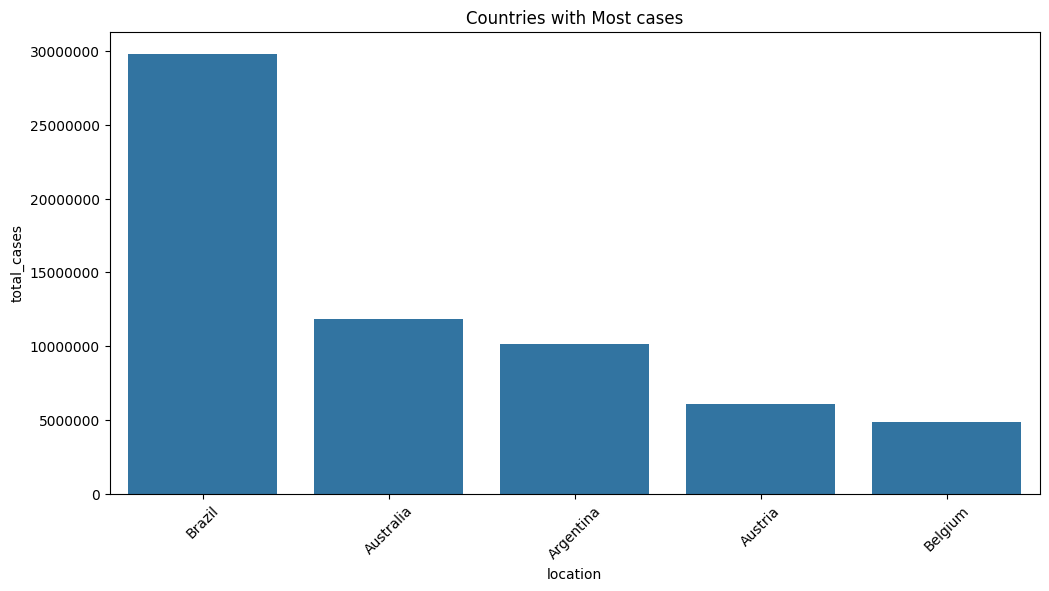

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
countries_most_cases = df_baru.groupby(['location'])[['total_cases']].max().reset_index().sort_values(by='total_cases', ascending=False).head(5).reset_index(drop=True)
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.xticks(rotation=45)
plt.title('Countries with Most cases')
sns.barplot(data=countries_most_cases, x='location', y='total_cases')

<Axes: title={'center': 'Countries with Most cases'}, xlabel='continent', ylabel='total_cases'>

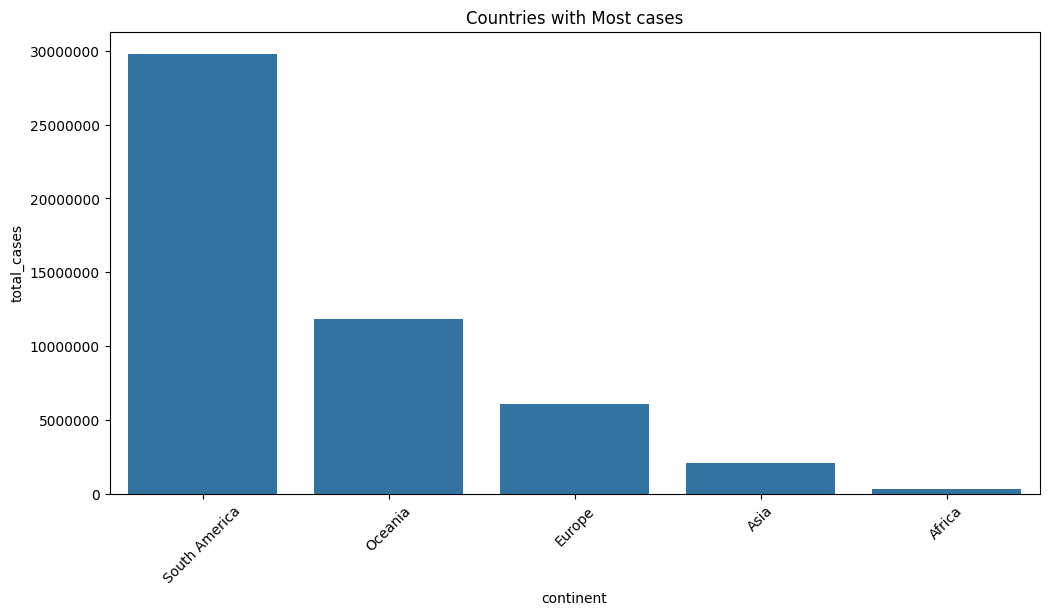

In [ ]:
# Plot Sunburst chart for Total Cases Over Time
plt.figure(figsize=(12,6))
countries_most_cases = df_baru.groupby(['continent'])[['total_cases']].max().reset_index().sort_values(by='total_cases', ascending=False).head(5).reset_index(drop=True)
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.xticks(rotation=45)
plt.title('Countries with Most cases')
sns.barplot(data=countries_most_cases, x='continent', y='total_cases')